## Importar IMDb dataset

50000 reseñas de peliculas altamente polarizadas, divididas 25000 y 25000 entre train y test. Cada conjunto esta dividido en 50% reseñas negativas y 50% reseñas positivas.

In [3]:
!nvidia-smi

Tue Feb  3 19:02:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA TITAN X (Pascal)        Off |   00000000:01:00.0 Off |                  N/A |
| 22%   42C    P0             73W /  250W |       8MiB /  12288MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!kill -9 2629799        

In [2]:
from keras.datasets import imdb

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(
num_words=10000)

2025-06-11 19:54:56.364258: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749682496.843583  530940 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749682496.986666  530940 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1749682498.246525  530940 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1749682498.246596  530940 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1749682498.246605  530940 computation_placer.cc:177] computation placer alr

In [3]:
print(train_data[0])
print(train_labels[0])
print(max([max(sequence) for sequence in train_data]))

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]
1
9999


Decodificar una reseña a ingles

In [4]:
word_index = imdb.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
decoded_review = ' '.join([reverse_word_index.get(i - 3, '?') for i in test_data[0]])

In [5]:
print(decoded_review)

? please give this one a miss br br ? ? and the rest of the cast rendered terrible performances the show is flat flat flat br br i don't know how michael madison could have allowed this one on his plate he almost seemed to know this wasn't going to work out and his performance was quite ? so all you madison fans give this a miss


## Preprocesado

Vectorizar las reseñas con una codificación ONE-HOT.

In [6]:
import numpy as np

"""Vectoriza un un conjunto de conjuntos de datos numericos en codificación ONE-HOT.
Persiste la información del contenido de cada conjunto pero se pierde todo lo relacionado
al orden y la cantidad de veces que aparece cada valor.

Keyword arguments:
sequences -- Conjunto de conjuntos de valores numericos.
dimension -- (def=10000) Cantidad de dimenciones a considerar para el tamaño de cada 
vectorizacion ONE-HOT.
Return: Conjunto de Conjuntos Vectorizado ONE-HOT
"""
def vectorize_sequences(sequences, dimension=10000):
    result = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        result[i, sequence] = 1
    return result
        
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

In [7]:
print(x_train[0])
wordsidx = np.where(x_train[0] == 1)[0]
print(wordsidx)
print([reverse_word_index.get(i - 3, '?') for i in wordsidx])

[0. 1. 1. ... 0. 0. 0.]
[   1    2    4    5    6    7    8    9   12   13   14   15   16   17
   18   19   21   22   25   26   28   30   32   33   35   36   38   39
   43   46   48   50   51   52   56   62   65   66   71   76   77   82
   87   88   92   98  100  103  104  106  107  112  113  117  124  130
  134  135  141  144  147  150  167  172  173  178  192  194  215  224
  226  256  283  284  297  316  317  336  381  385  386  400  407  447
  458  469  476  480  515  530  546  619  626  670  723  838  973 1029
 1111 1247 1334 1385 1415 1622 1920 2025 2071 2223 3766 3785 3941 4468
 4472 4536 4613 5244 5345 5535 5952 7486]
['?', '?', 'the', 'and', 'a', 'of', 'to', 'is', 'it', 'i', 'this', 'that', 'was', 'as', 'for', 'with', 'but', 'film', 'you', 'are', 'have', 'be', 'all', 'at', 'an', 'they', 'so', 'from', 'just', 'out', 'if', 'there', 'what', 'good', 'up', 'would', 'story', 'really', 'were', 'much', 'been', 'also', 'great', 'because', "don't", 'them', 'could', 'after', 'think', 'wa

Vectorizar etiquetas

In [8]:
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')
print(y_train)


[1. 0. 0. ... 0. 1. 0.]


## Building Network

In [9]:
from tensorflow.keras import models
from tensorflow.keras import layers

model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))
model.compile(optimizer='rmsprop',
            loss='binary_crossentropy',
            metrics=['acc'])

/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1749682518.655269  530940 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 11534 MB memory:  -> device: 0, name: NVIDIA TITAN X (Pascal), pci bus id: 0000:01:00.0, compute capability: 6.1


## Conjunto de Validación

In [10]:
x_val = x_train[:10000]
partial_x_train = x_train[10000:]
y_val = y_train[:10000]
partial_y_train = y_train[10000:]

## Entrenar modelo

In [11]:
history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val))

Epoch 1/20


I0000 00:00:1749682524.537912  531094 service.cc:152] XLA service 0x7f927c0071c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1749682524.537934  531094 service.cc:160]   StreamExecutor device (0): NVIDIA TITAN X (Pascal), Compute Capability 6.1
2025-06-11 19:55:24.784087: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1749682525.171845  531094 cuda_dnn.cc:529] Loaded cuDNN version 90300


25/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.7034 - loss: 0.6086

I0000 00:00:1749682527.023612  531094 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - acc: 0.7192 - loss: 0.5922 - val_acc: 0.8674 - val_loss: 0.3883
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.8958 - loss: 0.3279 - val_acc: 0.8629 - val_loss: 0.3419
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9237 - loss: 0.2406 - val_acc: 0.8892 - val_loss: 0.2812
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9417 - loss: 0.1841 - val_acc: 0.8866 - val_loss: 0.2779
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9485 - loss: 0.1598 - val_acc: 0.8849 - val_loss: 0.2798
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9594 - loss: 0.1321 - val_acc: 0.8839 - val_loss: 0.2956
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9669 - loss: 0.1120 - val_acc: 0.8817 - val_loss: 0.3151
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9728 - loss: 0.0973 - val_acc: 0.8716 - val_loss: 0.3606
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9773 - loss: 0.

In [12]:
history_dict = history.history
history_dict.keys()

dict_keys(['acc', 'loss', 'val_acc', 'val_loss'])

## Visualizar

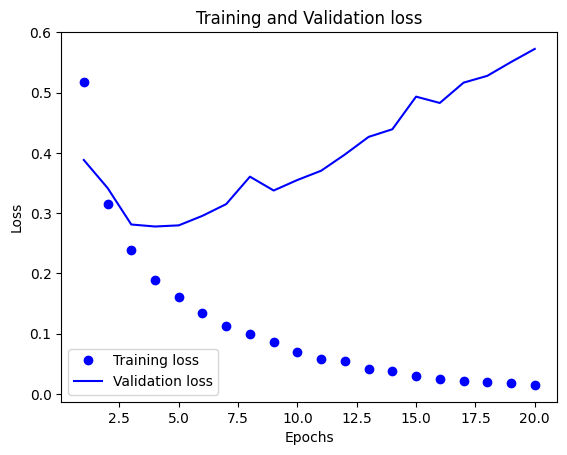

In [13]:
import matplotlib.pyplot as plt

history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']

epochs = range(1, len(loss_values) + 1)

plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

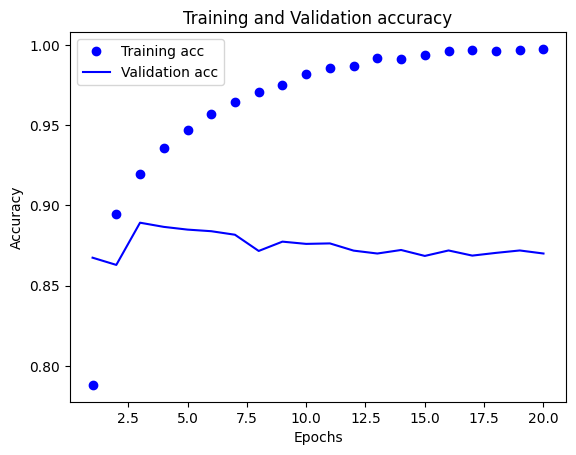

In [14]:
acc_values = history_dict['acc']
val_acc_values = history_dict['val_acc']

epochs = range(1, len(acc_values) + 1)

plt.plot(epochs, acc_values, 'bo', label='Training acc')
plt.plot(epochs, val_acc_values, 'b', label='Validation acc')
plt.title('Training and Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

## Cortar temprano el entrenamiento

En el caso anterior se aprecia un claro sobreentrenamiento a partir de la epoca 5. Vamos a repetir el entrenamiento pero ahora solo hasta esta epoca.

In [15]:
from tensorflow.keras import models
from tensorflow.keras import layers

model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['acc'])

# Notar que ya no se separa el subconjunto de datos de validación
model.fit(x_train, y_train, epochs=4, batch_size=512)

results = model.evaluate(x_test, y_test)

results

2025-06-11 19:55:39.636924: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1000000000 exceeds 10% of free system memory.
2025-06-11 19:55:40.919202: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1000000000 exceeds 10% of free system memory.


Epoch 1/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - acc: 0.6754 - loss: 0.6117
Epoch 2/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.8924 - loss: 0.3532
Epoch 3/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.9168 - loss: 0.2485
Epoch 4/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.9336 - loss: 0.1954


2025-06-11 19:55:46.055791: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1000000000 exceeds 10% of free system memory.
2025-06-11 19:55:46.731052: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1000000000 exceeds 10% of free system memory.


782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - acc: 0.8815 - loss: 0.2876


[0.28855276107788086, 0.8830400109291077]

probabilidad de reseña positiva cuando ´y´ tiende a 1

In [16]:
model.predict(x_test)

2025-06-11 19:55:49.853122: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 1000000000 exceeds 10% of free system memory.


782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


array([[0.1567453 ],
       [0.9946665 ],
       [0.69362175],
       ...,
       [0.08400366],
       [0.07020381],
       [0.38330576]], dtype=float32)

## 3.4.6 Mas experimentos
Variaciones de la red principal ejecutadas para analizar como difiere el modelo entrenado final y su rendimiento.

### Mas capas
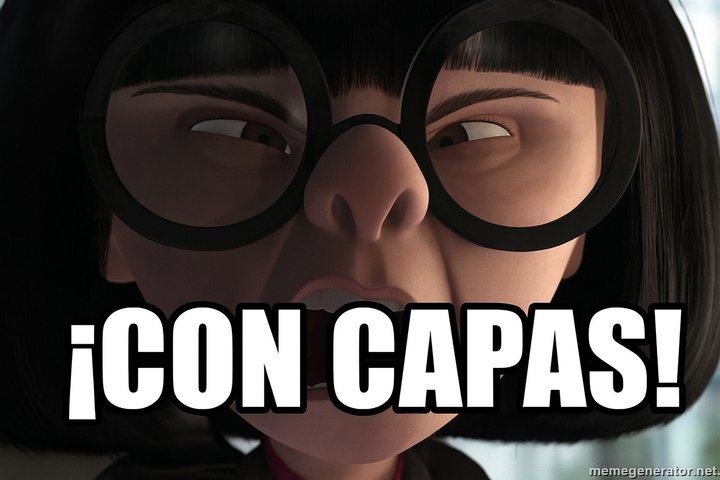

Antes se usaron 2 capas ocultas (16 neuronas cada una). Probar usando 3 capas y ver como esto afecta el accuracy en validación y test.

In [17]:
from tensorflow.keras import models
from tensorflow.keras import layers

model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))
model.compile(optimizer='rmsprop',
            loss='binary_crossentropy',
            metrics=['acc'])

history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - acc: 0.6729 - loss: 0.6306 - val_acc: 0.8535 - val_loss: 0.4193
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.8921 - loss: 0.3500 - val_acc: 0.8694 - val_loss: 0.3311
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9157 - loss: 0.2475 - val_acc: 0.8901 - val_loss: 0.2787
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9367 - loss: 0.1947 - val_acc: 0.8877 - val_loss: 0.2774
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9515 - loss: 0.1578 - val_acc: 0.8703 - val_loss: 0.3315
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - acc: 0.9549 - loss: 0.1345 - val_acc: 0.8581 - val_loss: 0.3795
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9613 - loss: 0.1189 - val_acc: 0.8825 - val_loss: 0.3102
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9769 - loss: 0.0850 - val_acc: 0.8821 - val_loss: 0.3258
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9836

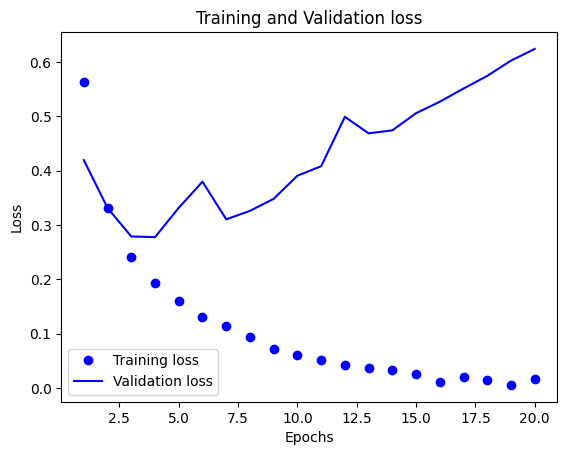

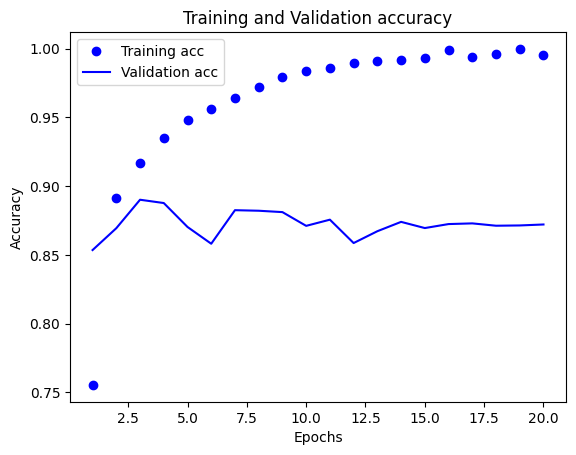

In [18]:
history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
acc_values = history_dict['acc']
val_acc_values = history_dict['val_acc']


import matplotlib.pyplot as plt

epochs = range(1, len(loss_values) + 1)

plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

plt.plot(epochs, acc_values, 'bo', label='Training acc')
plt.plot(epochs, val_acc_values, 'b', label='Validation acc')
plt.title('Training and Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

Al aumentar la complejidad de la red el sobre entrenamiento es mas pronunciado, mientras que las metricas son similares. 
No hay mas patrones que identificar en los datos de entrada que sean generalizables a los datos de testeo que no se perciban ya con la version de la red de 2 caps. Incrementar la cantidad de capas proboco que los patrones generalibles se aprendan antes y que el sobre aprendizaje de patrones tambien ocurra mas rapido.

Vista la situacion se repite el entrenamiento con la totalidad de los datos de train antes de que ocurra el sobre entrenamiento.

In [19]:
from tensorflow.keras import models
from tensorflow.keras import layers

model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['acc'])

# Notar que ya no se separa el subconjunto de datos de validación
model.fit(x_train, y_train, epochs=4, batch_size=512)

results = model.evaluate(x_test, y_test)

results

Epoch 1/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - acc: 0.7266 - loss: 0.5603
Epoch 2/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9028 - loss: 0.2780
Epoch 3/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9277 - loss: 0.1999
Epoch 4/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9380 - loss: 0.1722
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - acc: 0.8743 - loss: 0.3190


[0.31383347511291504, 0.8770400285720825]

El resultado fue menos de 1% mejor. 
El aumento de complejidad tubo un efecto positivo, aunque pequeño.

### Mas unidades

Ahora probar incrementando a 32 y a 64 la cantidad de unidades por capa oculta.

#### 32 unidades por capa

In [20]:
from tensorflow.keras import models
from tensorflow.keras import layers

model = models.Sequential()
model.add(layers.Dense(32, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(32, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))
model.compile(optimizer='rmsprop',
            loss='binary_crossentropy',
            metrics=['acc'])

history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - acc: 0.6741 - loss: 0.6178 - val_acc: 0.8546 - val_loss: 0.4171
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.8861 - loss: 0.3619 - val_acc: 0.8830 - val_loss: 0.3166
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9171 - loss: 0.2529 - val_acc: 0.8875 - val_loss: 0.2870
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - acc: 0.9290 - loss: 0.2056 - val_acc: 0.8889 - val_loss: 0.2792
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9500 - loss: 0.1621 - val_acc: 0.8871 - val_loss: 0.2830
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9571 - loss: 0.1361 - val_acc: 0.8851 - val_loss: 0.2903
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - acc: 0.9653 - loss: 0.1125 - val_acc: 0.8858 - val_loss: 0.3075
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9721 - loss: 0.0995 - val_acc: 0.8775 - val_loss: 0.3275
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9774

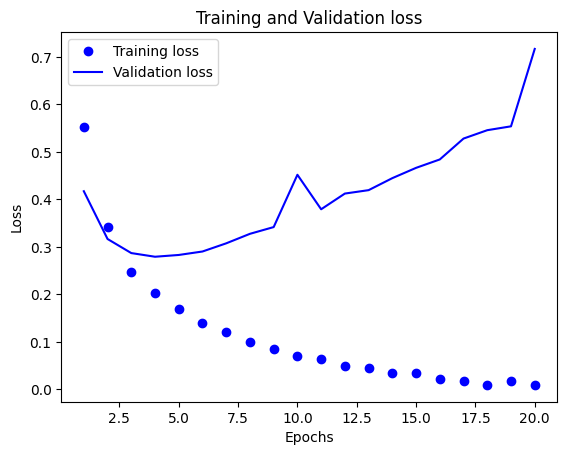

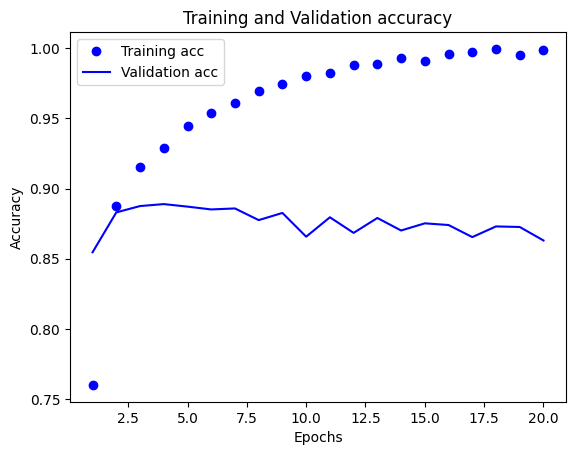

In [21]:
history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
acc_values = history_dict['acc']
val_acc_values = history_dict['val_acc']


import matplotlib.pyplot as plt

epochs = range(1, len(loss_values) + 1)

plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

plt.plot(epochs, acc_values, 'bo', label='Training acc')
plt.plot(epochs, val_acc_values, 'b', label='Validation acc')
plt.title('Training and Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [24]:
# Early Stoping
from tensorflow.keras import models
from tensorflow.keras import layers

model = models.Sequential()
model.add(layers.Dense(32, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(32, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['acc'])

# Notar que ya no se separa el subconjunto de datos de validación
model.fit(x_train, y_train, epochs=4, batch_size=512)

results = model.evaluate(x_test, y_test)

results

Epoch 1/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - acc: 0.7208 - loss: 0.5619
Epoch 2/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9031 - loss: 0.2745
Epoch 3/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9181 - loss: 0.2168
Epoch 4/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9348 - loss: 0.1801
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - acc: 0.8821 - loss: 0.2983


[0.295577734708786, 0.8835600018501282]

#### 64 unidades por capa

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - acc: 0.6687 - loss: 0.5940 - val_acc: 0.8705 - val_loss: 0.3467
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.8915 - loss: 0.2987 - val_acc: 0.8868 - val_loss: 0.2857
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9209 - loss: 0.2176 - val_acc: 0.8572 - val_loss: 0.3475
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9350 - loss: 0.1797 - val_acc: 0.8484 - val_loss: 0.3846
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9388 - loss: 0.1630 - val_acc: 0.8858 - val_loss: 0.2883
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9648 - loss: 0.1138 - val_acc: 0.8601 - val_loss: 0.3947
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9593 - loss: 0.1159 - val_acc: 0.8800 - val_loss: 0.3282
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - acc: 0.9781 - loss: 0.0732 - val_acc: 0.8803 - val_loss: 0.3433
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9795

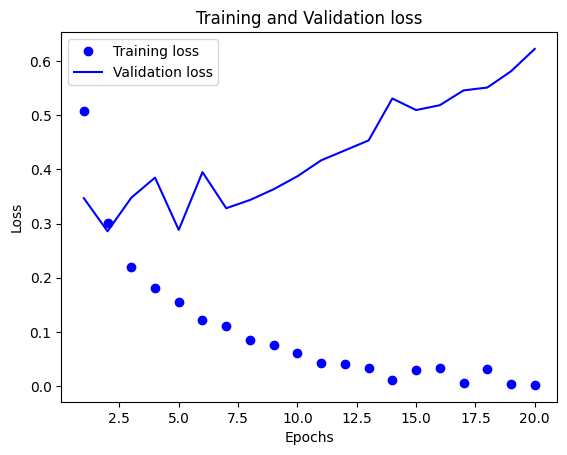

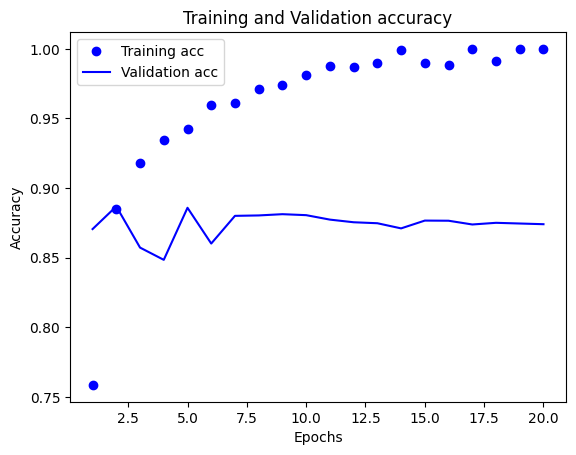

In [23]:
from tensorflow.keras import models
from tensorflow.keras import layers

model = models.Sequential()
model.add(layers.Dense(64, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))
model.compile(optimizer='rmsprop',
            loss='binary_crossentropy',
            metrics=['acc'])

history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val))

#---------------------------------------------

history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
acc_values = history_dict['acc']
val_acc_values = history_dict['val_acc']

import matplotlib.pyplot as plt

epochs = range(1, len(loss_values) + 1)

plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

plt.plot(epochs, acc_values, 'bo', label='Training acc')
plt.plot(epochs, val_acc_values, 'b', label='Validation acc')
plt.title('Training and Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [25]:
# Early Stoping
from tensorflow.keras import models
from tensorflow.keras import layers

model = models.Sequential()
model.add(layers.Dense(64, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['acc'])

# Notar que ya no se separa el subconjunto de datos de validación
model.fit(x_train, y_train, epochs=2, batch_size=512)

results = model.evaluate(x_test, y_test)

results

Epoch 1/2
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - acc: 0.7249 - loss: 0.5430
Epoch 2/2
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.8911 - loss: 0.2735
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - acc: 0.8730 - loss: 0.3126


[0.3075973391532898, 0.8746799826622009]

#### Resultados
Los resultados de ejecutar con 32 unidades ocultas fueron similares a los de ejecutar con una capa mas. El incremento de complejidad funciona tanto en ancho como en alto.

El experimento con 64 sigue la misma tendencia a un nivel acorde a su cantidad de unidades ocultas.

Cabe destacar que en este caso concreto es mas rentable a nivel cantidad de operacioens agregar una capa con 16 neuronas, cosa que dada HU (cantidad de unidades ocultas) entonces:
$$
HU = 16 * 3 = 42
$$
Si se incrementa la cantidad de neuronas por capa entonces:
$$
HU = 32 * 2 = 64
$$
Mucho mas notorio cuando se incrementa a 64 neuronas por capa:
$$
HU = 64 * 2 = 128
$$
Claramente en este caso particular renta mas incrementar ancho que alto para un resultado similar.


### Error cuadratico medio (mse) en vez de Entropia cruzada Binaria (binary_crossentropy)
Ahora probar usando como funcion de error 'mse' en vez de 'binary_crossentropy'.


Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - acc: 0.6738 - loss: 0.2116 - val_acc: 0.8435 - val_loss: 0.1318
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.8809 - loss: 0.1092 - val_acc: 0.8779 - val_loss: 0.0999
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9172 - loss: 0.0761 - val_acc: 0.8878 - val_loss: 0.0876
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9320 - loss: 0.0612 - val_acc: 0.8721 - val_loss: 0.0942
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9414 - loss: 0.0528 - val_acc: 0.8749 - val_loss: 0.0923
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9510 - loss: 0.0450 - val_acc: 0.8786 - val_loss: 0.0874
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9615 - loss: 0.0382 - val_acc: 0.8871 - val_loss: 0.0835
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9674 - loss: 0.0335 - val_acc: 0.8854 - val_loss: 0.0850
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9719

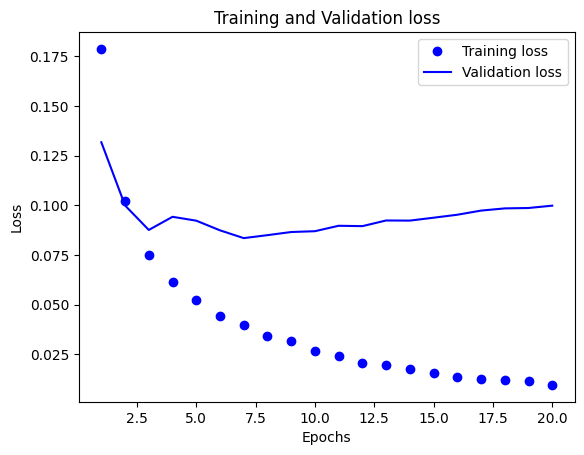

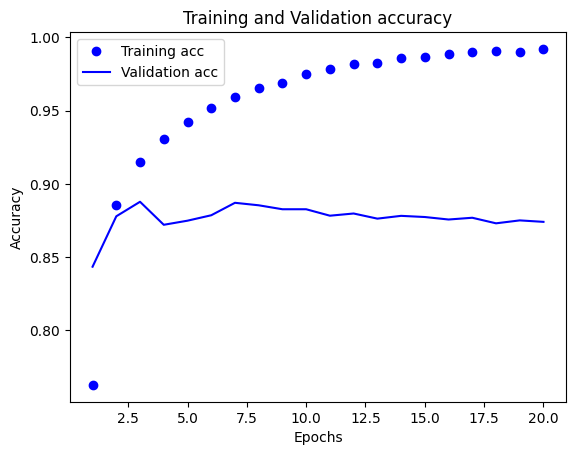

In [27]:
from tensorflow.keras import models
from tensorflow.keras import layers

model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))
model.compile(optimizer='rmsprop',
            loss='mse',
            metrics=['acc'])

history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val))

#---------------------------------------------

history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
acc_values = history_dict['acc']
val_acc_values = history_dict['val_acc']

import matplotlib.pyplot as plt

epochs = range(1, len(loss_values) + 1)

plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

plt.plot(epochs, acc_values, 'bo', label='Training acc')
plt.plot(epochs, val_acc_values, 'b', label='Validation acc')
plt.title('Training and Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [30]:
# Early Stoping
from tensorflow.keras import models
from tensorflow.keras import layers

model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop',
    loss='mse',
    metrics=['acc'])

# Notar que ya no se separa el subconjunto de datos de validación
model.fit(x_train, y_train, epochs=4, batch_size=512)

results = model.evaluate(x_test, y_test)

results

Epoch 1/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - acc: 0.7122 - loss: 0.1972
Epoch 2/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.8987 - loss: 0.0894
Epoch 3/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9195 - loss: 0.0684
Epoch 4/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9282 - loss: 0.0588
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - acc: 0.8831 - loss: 0.0849


[0.08421782404184341, 0.8851199746131897]

Se obtubo un acc similar pero con un loss mucho menor (1/3 del original). Es un comportamiento inesperado ya que se asume que para problemas de clasificacion binaria, la funcion de error binary_crossentropy es mas adecuada que mse. Parece que en este caso concreto no es asi.

Reflexionando acerca de ello capaz tiene que ver con que a medida que uno esta mas cerca de los extremos (0, 1) binary_crossentropy sugiere cambios mas drasticos. Esto puede implicar que en este caso particular se "salte" la mejor configuracion de parametros. Por otro lado mse termina sugiriendo cambios mas pequeños lo que hace que la funcion halle una mejor convinacion. 
NOTA: La misma situacion deberia poder lograrse reduciendo el valor de la tasa de aprendizaje.

### Ahora con Tanh
Usar la funcion de activación `tanh` en vez de `relu`. `tanh` fue una funcion de activación popular en los primeros dias de las redes neuronales.

`tanh` es mas costosa computacionalmente que `relu`. Tambien implica una velociadad de entrenamiento mas lenta. Por otro lado es interesante notar que si una neurona `relu` siempre recive valores negativos su gradiente siempre sera cero, por lo que estara "muerta" ya que deja de aprender.

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - acc: 0.6934 - loss: 0.5849 - val_acc: 0.8589 - val_loss: 0.3889
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.8958 - loss: 0.3208 - val_acc: 0.8648 - val_loss: 0.3269
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9231 - loss: 0.2281 - val_acc: 0.8882 - val_loss: 0.2727
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9463 - loss: 0.1654 - val_acc: 0.8883 - val_loss: 0.2723
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9561 - loss: 0.1355 - val_acc: 0.8869 - val_loss: 0.2865
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9701 - loss: 0.1018 - val_acc: 0.8840 - val_loss: 0.3210
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9741 - loss: 0.0883 - val_acc: 0.8819 - val_loss: 0.3379
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9830 - loss: 0.0647 - val_acc: 0.8777 - val_loss: 0.3728
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9846

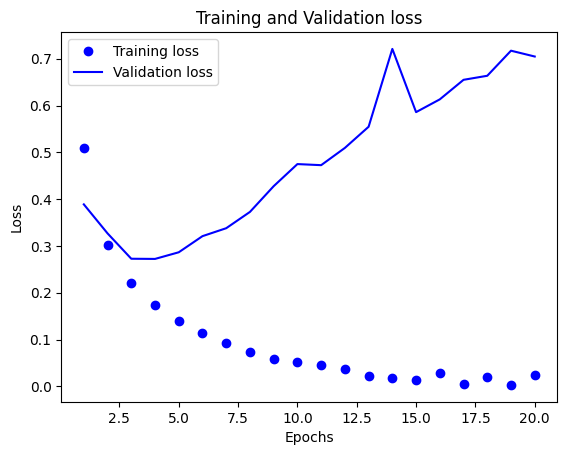

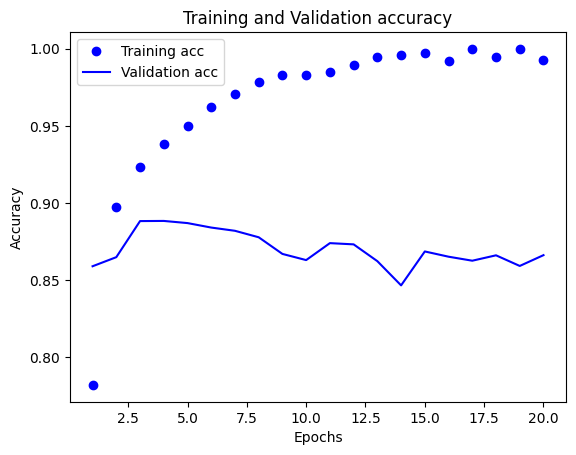

In [31]:
from tensorflow.keras import models
from tensorflow.keras import layers

model = models.Sequential()
model.add(layers.Dense(16, activation='tanh', input_shape=(10000,)))
model.add(layers.Dense(16, activation='tanh'))
model.add(layers.Dense(1, activation='sigmoid'))
model.compile(optimizer='rmsprop',
            loss='binary_crossentropy',
            metrics=['acc'])

history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val))

#---------------------------------------------

history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
acc_values = history_dict['acc']
val_acc_values = history_dict['val_acc']

import matplotlib.pyplot as plt

epochs = range(1, len(loss_values) + 1)

plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

plt.plot(epochs, acc_values, 'bo', label='Training acc')
plt.plot(epochs, val_acc_values, 'b', label='Validation acc')
plt.title('Training and Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [32]:
# Early Stoping
from tensorflow.keras import models
from tensorflow.keras import layers

model = models.Sequential()
model.add(layers.Dense(16, activation='tanh', input_shape=(10000,)))
model.add(layers.Dense(16, activation='tanh'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['acc'])

# Notar que ya no se separa el subconjunto de datos de validación
model.fit(x_train, y_train, epochs=4, batch_size=512)

results = model.evaluate(x_test, y_test)

results

Epoch 1/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - acc: 0.7442 - loss: 0.5266
Epoch 2/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9069 - loss: 0.2543
Epoch 3/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9361 - loss: 0.1817
Epoch 4/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9444 - loss: 0.1565
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - acc: 0.8741 - loss: 0.3220


[0.3166165351867676, 0.8766000270843506]

Los resultados con la funcion de activacion `tanh` fueron similares. La unica peculiaridad que percibi es que el sobre entrenamiento ocurrio rapido.